# MeshVTON — İnteraktif Test (kendi modelimiz)

Kişi fotoğrafı + giysi `.obj` (+ texture) yükle → eğitilmiş MeshVTON checkpoint'iyle try-on sonucu al.
İstersen 0/90/180/270° için ayrı ayrı üret (tek fotodan çok açı = 3D koşullama avantajı).

**Sıra:** hücreleri yukarıdan aşağı çalıştır. Ağır modeller (FLUX 12B, HMR2) bir kez yüklenir, sonraki üretimlerde tekrar yüklenmez.


In [ ]:
#@title 0) GitHub'dan son kodu çek (yeni push sonrası SADECE bunu çalıştır)
import os, sys
if not os.path.exists('/content/MeshVTON'):
    !git clone -q https://github.com/SerhanTelatar/MeshVTON /content/MeshVTON
%cd /content/MeshVTON
!git fetch -q origin && git reset --hard origin/main   # lokal kalıntıları ez, son main'e eşitle
!git log --oneline -3

# Yüklü meshvton2 modüllerini boşalt -> runtime restart GEREKMEDEN yeni kod import edilir.
for m in [m for m in list(sys.modules) if m.startswith('meshvton2')]:
    del sys.modules[m]
if '/content/MeshVTON/v2' not in sys.path:
    sys.path.insert(0, '/content/MeshVTON/v2')
print('kod güncel. NOT: 3. hücredeki STATE eski sınıflardan kalmış olabilir —')
print('değişiklik model/builder koduna dokunduysa 3. hücreyi (ve 5-6yı) yeniden çalıştır.')


/content/MeshVTON
HEAD is now at 6aec790 commit
6aec790 (HEAD -> main, origin/main, origin/HEAD) commit
7b737b5 commit
a1d2f65 commit
kod güncel. NOT: 3. hücredeki STATE eski sınıflardan kalmış olabilir —
değişiklik model/builder koduna dokunduysa 3. hücreyi (ve 5-6yı) yeniden çalıştır.


In [ ]:
#@title 1) Kurulum (~2-3 dk; Colab GPU şart — A100/L4 önerilir)
import os, importlib.util, subprocess, shutil
if not os.path.exists('/content/MeshVTON'):
    !git clone -q https://github.com/SerhanTelatar/MeshVTON /content/MeshVTON
%cd /content/MeshVTON
!git pull -q

!pip -q install "diffusers>=0.34" "peft>=0.14" lpips einops sentencepiece trimesh smplx pyrender onnxruntime
!pip -q uninstall -y pyopengl PyOpenGL-accelerate > /dev/null 2>&1
!pip -q install "git+https://github.com/mmatl/pyopengl.git"
if importlib.util.find_spec('hmr2') is None:
    !pip -q install "git+https://github.com/shubham-goel/4D-Humans.git"
!apt-get -qq install -y libglu1-mesa libosmesa6 > /dev/null 2>&1

# EGL çalışıyorsa onu, yoksa OSMesa (yazılımsal)
_probe = subprocess.run(["python", "-c",
    'import os;os.environ["PYOPENGL_PLATFORM"]="egl";'
    'import pyrender;r=pyrender.OffscreenRenderer(16,16);r.delete();print("egl-ok")'],
    capture_output=True, text=True)
os.environ['PYOPENGL_PLATFORM'] = 'egl' if 'egl-ok' in _probe.stdout else 'osmesa'
print('GL platform:', os.environ['PYOPENGL_PLATFORM'])

# IDM-VTON yalnız KİŞİ ön-işlemesi için (parsing + openpose)
if not os.path.exists('/content/IDM-VTON'):
    !git clone -q https://github.com/yisol/IDM-VTON /content/IDM-VTON
from huggingface_hub import hf_hub_download
for repo_path in ('humanparsing/parsing_atr.onnx',
                  'humanparsing/parsing_lip.onnx',
                  'openpose/ckpts/body_pose_model.pth'):
    local = f'/content/IDM-VTON/ckpt/{repo_path}'
    if not (os.path.exists(local) and os.path.getsize(local) > 1_000_000):
        os.makedirs(os.path.dirname(local), exist_ok=True)
        shutil.copy(hf_hub_download('yisol/IDM-VTON', repo_path), local)
    assert os.path.getsize(local) > 1_000_000, f'bozuk indirme: {local}'

# FLUX.1 gated -> Colab Secrets'a HF_TOKEN ekle (soldaki anahtar simgesi)
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
print('Kurulum OK')


/content/MeshVTON
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 104.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 139.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 80.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 78.6 MB/s eta 0:00:00
GL platform: egl


humanparsing/parsing_atr.onnx:   0%|          | 0.00/267M [00:00<?, ?B/s]

humanparsing/parsing_lip.onnx:   0%|          | 0.00/267M [00:00<?, ?B/s]

openpose/ckpts/body_pose_model.pth:   0%|          | 0.00/209M [00:00<?, ?B/s]

Kurulum OK


In [ ]:
#@title 2) SMPL-X + HMR2 ağırlıkları (Drive'dan; build_conditioning bunlarsız çalışmaz)
import os, sys, glob, shutil
sys.path.insert(0, '/content/MeshVTON/v2')
from google.colab import drive
drive.mount('/content/drive')
D = '/content/drive/MyDrive/MeshVTON'   # gerekirse kendi Drive düzenine göre değiştir

# SMPL-X neutral modeli
os.makedirs('/content/MeshVTON/checkpoints/pretrained/smplx', exist_ok=True)
!cp $D/smplx/SMPLX_NEUTRAL.* /content/MeshVTON/checkpoints/pretrained/smplx/
os.environ['SMPLX_MODEL_DIR'] = '/content/MeshVTON/checkpoints/pretrained/smplx'

# HMR2 ağırlıkları (bir kez ~3.5GB) + SMPL neutral pkl
from meshvton2.conditioning.body import _patch_torch_load_weights_only
import torch as _torch; _patch_torch_load_weights_only(_torch)
from hmr2.models import download_models
from hmr2.configs import CACHE_DIR_4DHUMANS
download_models(CACHE_DIR_4DHUMANS)
smpl_dir = f"{CACHE_DIR_4DHUMANS}/data/smpl"; os.makedirs(smpl_dir, exist_ok=True)
cands = glob.glob(f'{D}/smpl/*neutral*lbs*.pkl') + glob.glob(f'{D}/smpl/SMPL_NEUTRAL.pkl')
assert cands, "SMPL neutral pkl yok -> Drive/MeshVTON/smpl/ (smplify.is.tue.mpg.de)"
shutil.copy(cands[0], f"{smpl_dir}/SMPL_NEUTRAL.pkl")
print('SMPL-X + HMR2 hazır')


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



Extracting file: hmr2_data.tar.gz
SMPL-X + HMR2 hazır


In [ ]:
#@title 3) Modelleri BİR kez yükle (FLUX 12B + HMR2 + parser)  —  ~2-4 dk
# Ayarlar:
CHECKPOINT = '/content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt'  # eğitilmiş MeshVTON; None => stok FLUX (eğitimsiz)
SIZE = (1024, 768)  # (H, W) — base.yaml ile aynı, DEĞİŞTİRME

import yaml
from pathlib import Path
from meshvton2.conditioning.builder import assert_real_impl
from meshvton2.conditioning.body import build_hmr2_backend
from meshvton2.conditioning.person import PersonPreprocessor
from meshvton2.model.flux_tryon import FluxTryOnSampler

assert_real_impl()
base = yaml.safe_load(Path('/content/MeshVTON/v2/configs/base.yaml').read_text())

# globals cache: hücreyi tekrar çalıştırırsan yeniden yüklemez
if 'STATE' not in globals():
    STATE = {}
if 'prep' not in STATE:
    STATE['prep'] = PersonPreprocessor('/content/IDM-VTON')
if 'hmr2' not in STATE:
    STATE['hmr2'] = build_hmr2_backend()
if STATE.get('ckpt') != CHECKPOINT:
    STATE['sampler'] = FluxTryOnSampler(
        base['model']['flux_fill_repo'],
        checkpoint=CHECKPOINT, prompt=base['model']['prompt'])
    STATE['ckpt'] = CHECKPOINT
print('Modeller hazır. checkpoint =', CHECKPOINT)


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/540 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

FluxTrainModule hazır — eğitilebilir param: 112,459,776
checkpoint yüklendi: /content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt (457 tensör)
Modeller hazır. checkpoint = /content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt


In [ ]:
#@title 4) Kişi fotoğrafları + giysi .obj yükle (texture YOK)
# Kişi ve giysi AYRI klasörlere kaydedilir (aksi halde loader kişi fotosunu
# yanlışlıkla giysi texture'ı sanabiliyor). Texture kullanmıyoruz.
from google.colab import files
import os, shutil

PDIR, GDIR = '/content/uploads/person', '/content/uploads/garment'
for d in (PDIR, GDIR):
    shutil.rmtree(d, ignore_errors=True); os.makedirs(d)

print('>> KİŞİ fotoğraflarını seç (Birden fazla dosya seçebilirsiniz):')
up_persons = files.upload()
PERSON_PATHS = []
for fname, data in up_persons.items():
    path = f'{PDIR}/{fname}'
    open(path, 'wb').write(data)
    PERSON_PATHS.append(path)

print('\n>> Giysi .OBJ dosyasını seç:')
up_garment = files.upload()
OBJ_PATH = f'{GDIR}/' + next(iter(up_garment))
open(OBJ_PATH, 'wb').write(next(iter(up_garment.values())))

print('\nkişiler:', PERSON_PATHS)
print('obj   :', OBJ_PATH)
print('NOT: texture yok -> model desen/rengi KOPYALAMAZ; yalnız yerleşim/şekil test edilir.')

# İPUCU: gerçek renk/desen için yükleme yerine DATASET giysisi kullan — loader
# .obj'nin yanındaki texture PNG'yi otomatik bulur (2. hücre zip'i açmıştı):
#   OBJ_PATH = '/content/MeshVTON/data/garments_3d/<giysi_klasörü>/mesh.obj'
#   !find /content/MeshVTON/data/garments_3d -name "*.obj" | head   # listelemek için

>> KİŞİ fotoğraflarını seç (Birden fazla dosya seçebilirsiniz):


Saving 05104_00_upper_body__00259_Top_000.person.png to 05104_00_upper_body__00259_Top_000.person.png
Saving ChatGPT Image Jul 8, 2026, 10_51_07 PM.png to ChatGPT Image Jul 8, 2026, 10_51_07 PM.png
Saving ChatGPT Image Jul 8, 2026, 10_51_15 PM.png to ChatGPT Image Jul 8, 2026, 10_51_15 PM.png
Saving ChatGPT Image Jul 8, 2026, 10_51_19 PM.png to ChatGPT Image Jul 8, 2026, 10_51_19 PM.png

>> Giysi .OBJ dosyasını seç:


Saving mesh.obj to mesh.obj

kişiler: ['/content/uploads/person/05104_00_upper_body__00259_Top_000.person.png', '/content/uploads/person/ChatGPT Image Jul 8, 2026, 10_51_07 PM.png', '/content/uploads/person/ChatGPT Image Jul 8, 2026, 10_51_15 PM.png', '/content/uploads/person/ChatGPT Image Jul 8, 2026, 10_51_19 PM.png']
obj   : /content/uploads/garment/mesh.obj
NOT: texture yok -> model desen/rengi KOPYALAMAZ; yalnız yerleşim/şekil test edilir.


texture yok -> düz gri appearance referansı.

KİŞİ 1 TEŞHİS: 05104_00_upper_body__00259_Top_000.person.png


100%|██████████| 1/1 [00:00<00:00,  1.73it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  b3 = torch.cross(b1, b2)


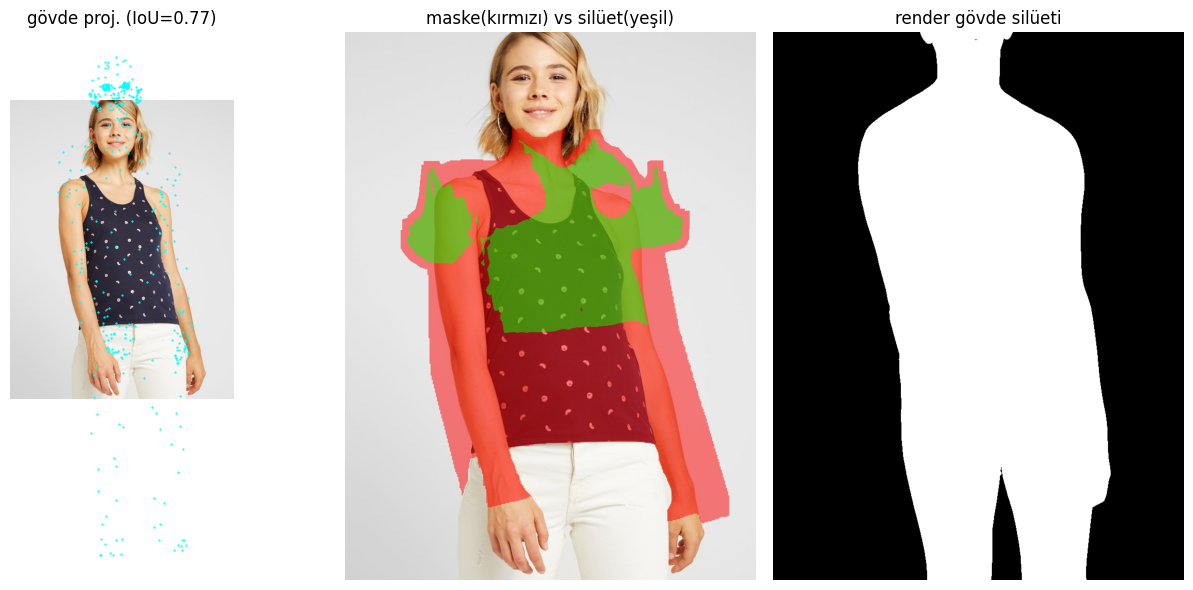

IoU: 0.774 | Kapsama: 1.000 | Drape: 0.401

KİŞİ 2 TEŞHİS: ChatGPT Image Jul 8, 2026, 10_51_07 PM.png


100%|██████████| 1/1 [00:00<00:00,  2.88it/s]


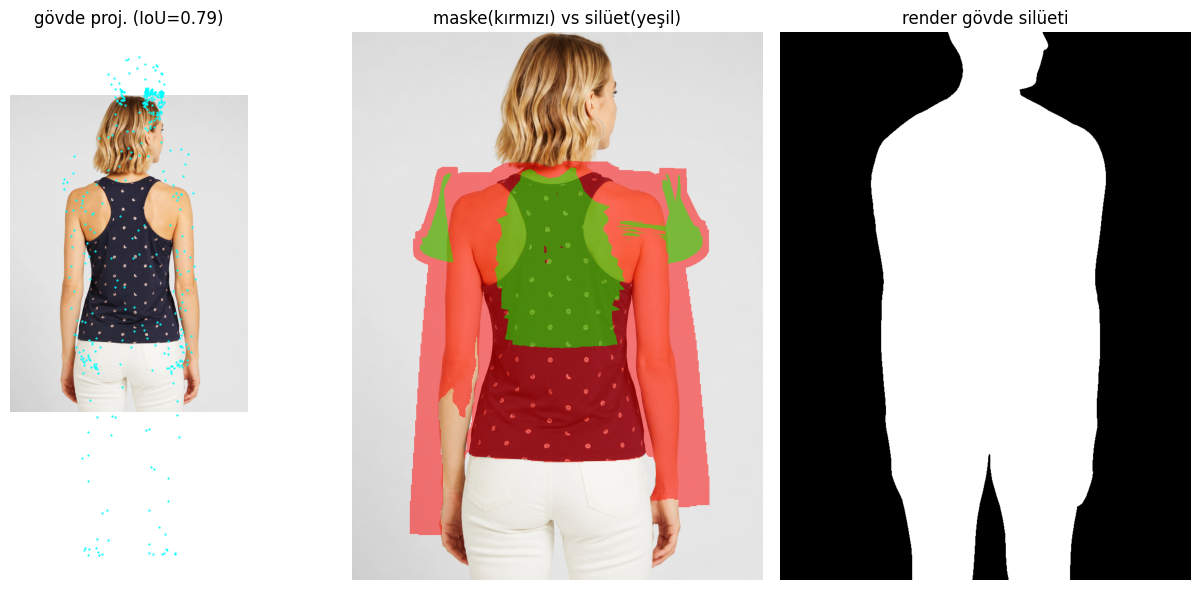

IoU: 0.791 | Kapsama: 1.000 | Drape: 0.405

KİŞİ 3 TEŞHİS: ChatGPT Image Jul 8, 2026, 10_51_15 PM.png


100%|██████████| 1/1 [00:00<00:00,  3.23it/s]


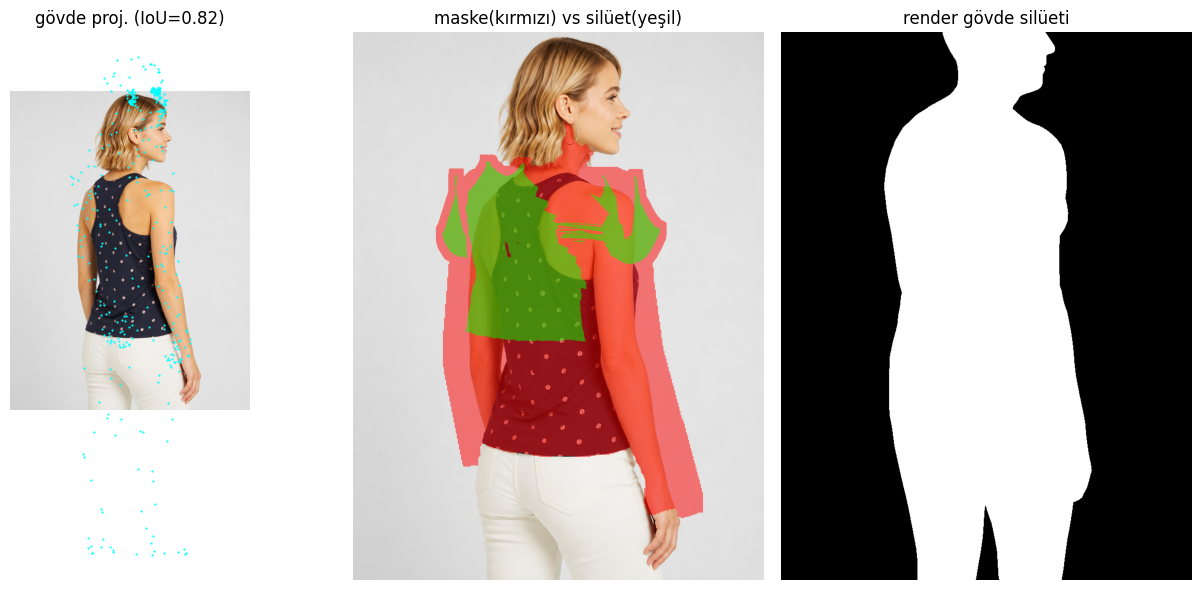

IoU: 0.824 | Kapsama: 1.000 | Drape: 0.400

KİŞİ 4 TEŞHİS: ChatGPT Image Jul 8, 2026, 10_51_19 PM.png


100%|██████████| 1/1 [00:00<00:00,  1.83it/s]


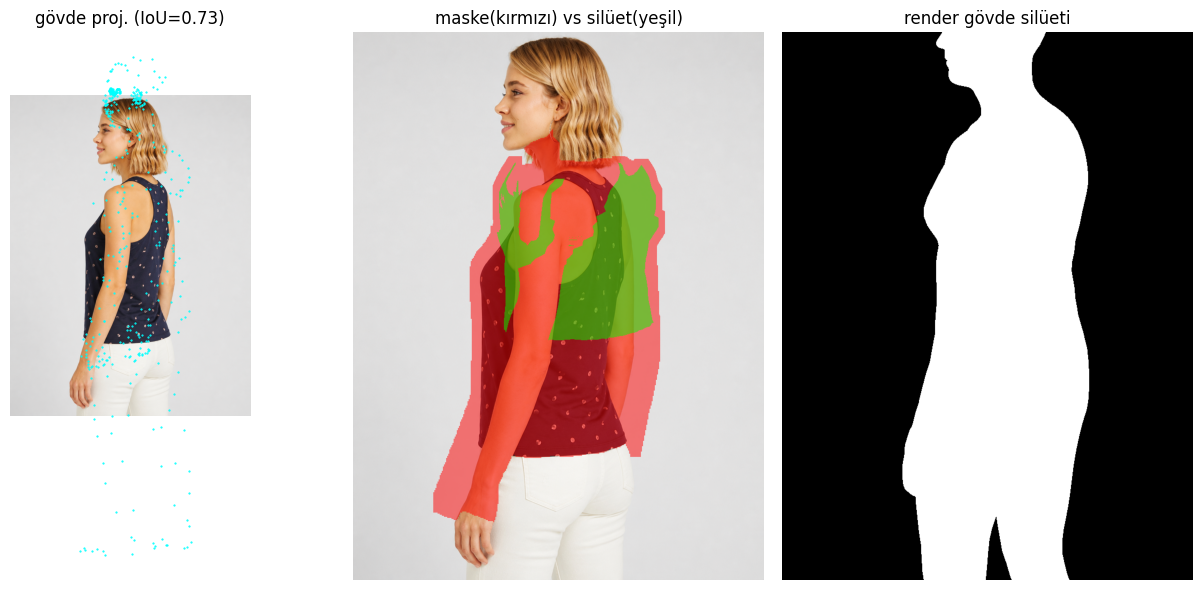

IoU: 0.726 | Kapsama: 1.000 | Drape: 0.382


In [ ]:
#@title 5) Koşullama kur + TEŞHİS (Tüm kişiler için)
ANGLES = [0]            #@param  ör. [0]  veya  [0, 90, 180, 270]  (0 = fotonun kendi açısı)
HANG_PAD = -0.06        #@param  giysi askı payı [m]. Silüet çok YUKARIDAYSA küçült (0.06 -> -0.06 ~ -0.10), aşağıdaysa artır. Örneklemeden önce burada kalibre et.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from meshvton2.conditioning.builder import build_conditioning, PhotoView, OrbitView
from meshvton2.conditioning.garment import load_garment_asset
from meshvton2.conditioning.person import person_square_bbox
from meshvton2.conditioning.body import get_body_model
from meshvton2.conditioning import camera as cam_mod
from meshvton2.conditioning.render import render_body_mask

prep, hmr2 = STATE['prep'], STATE['hmr2']

# Giysi mesh'ini yükle (tek giysi tüm kişiler için)
asset = load_garment_asset(OBJ_PATH, texture_path=None, allow_untextured=True,
                           garment_id=os.path.splitext(os.path.basename(OBJ_PATH))[0])
if asset.texture is None:
    tex = np.full((64, 64, 3), 200, np.uint8)
    uv = asset.uv if asset.uv is not None else np.zeros((len(asset.verts), 2), np.float32)
    asset = replace(asset, texture=tex, uv=uv)
    print('texture yok -> düz gri appearance referansı.')

ALL_PERSON_DATA = []

for p_idx, p_path in enumerate(PERSON_PATHS):
    print(f"\n{'='*50}\nKİŞİ {p_idx+1} TEŞHİS: {os.path.basename(p_path)}")

    pp = prep.process(p_path, size=SIZE)
    params = hmr2(pp.image, bbox=person_square_bbox(pp))

    bundles = {a: build_conditioning(pp.image, params, asset,
                                     PhotoView() if a == 0 else OrbitView(a),
                                     size=SIZE, person_prep=pp, hang_pad=HANG_PAD)
               for a in ANGLES}

    b0 = bundles.get(0) or build_conditioning(pp.image, params, asset, PhotoView(),
                                              size=SIZE, person_prep=pp, hang_pad=HANG_PAD)
    cam = b0.camera
    body = get_body_model()(params)
    h, w = SIZE

    uv_pix = cam_mod.project(cam, body['verts'])
    ok = ~np.isnan(uv_pix).any(1)
    body_m = render_body_mask(body['verts'], body['faces'], cam, size=SIZE)
    parse_full = cv2.resize(pp.parse, (w, h), interpolation=cv2.INTER_NEAREST) > 0
    reproj_iou = (parse_full & body_m).sum() / max((parse_full | body_m).sum(), 1)

    sil = b0.control_depth_sil[2].numpy() > 0
    msk = b0.inpaint_mask[0].numpy() > 0.5
    cover = (sil & msk).sum() / max(sil.sum(), 1)

    overlay = pp.image.copy()
    overlay[msk] = (overlay[msk] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)
    overlay[sil] = (overlay[sil] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)

    fig, ax = plt.subplots(1, 3, figsize=(13, 6))
    ax[0].imshow(pp.image); ax[0].scatter(uv_pix[ok, 0][::25], uv_pix[ok, 1][::25], s=0.3, c='cyan')
    ax[0].set_title(f'gövde proj. (IoU={reproj_iou:.2f})')
    ax[1].imshow(overlay); ax[1].set_title('maske(kırmızı) vs silüet(yeşil)')
    ax[2].imshow(body_m, cmap='gray'); ax[2].set_title('render gövde silüeti')
    for x in ax: x.axis('off')
    plt.tight_layout(); plt.show()

    meta = b0.meta
    print(f"IoU: {reproj_iou:.3f} | Kapsama: {cover:.3f} | Drape: {meta.get('drape_extent_ratio'):.3f}")
    ALL_PERSON_DATA.append({'path': p_path, 'pp': pp, 'bundles': bundles})


ÜRETİLİYOR: KİŞİ 1 (05104_00_upper_body__00259_Top_000.person.png)


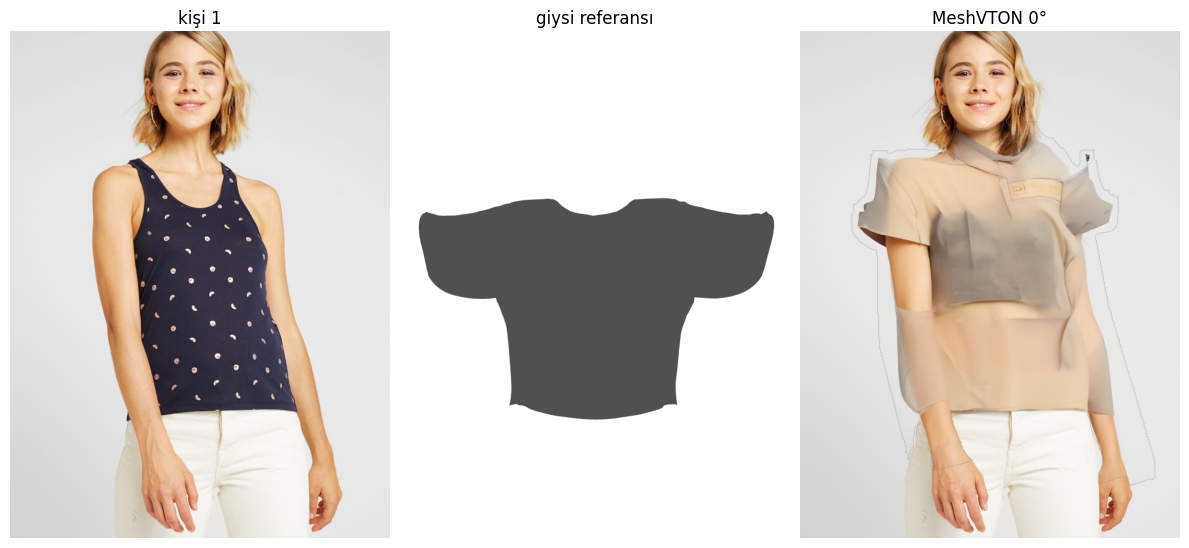


ÜRETİLİYOR: KİŞİ 2 (ChatGPT Image Jul 8, 2026, 10_51_07 PM.png)


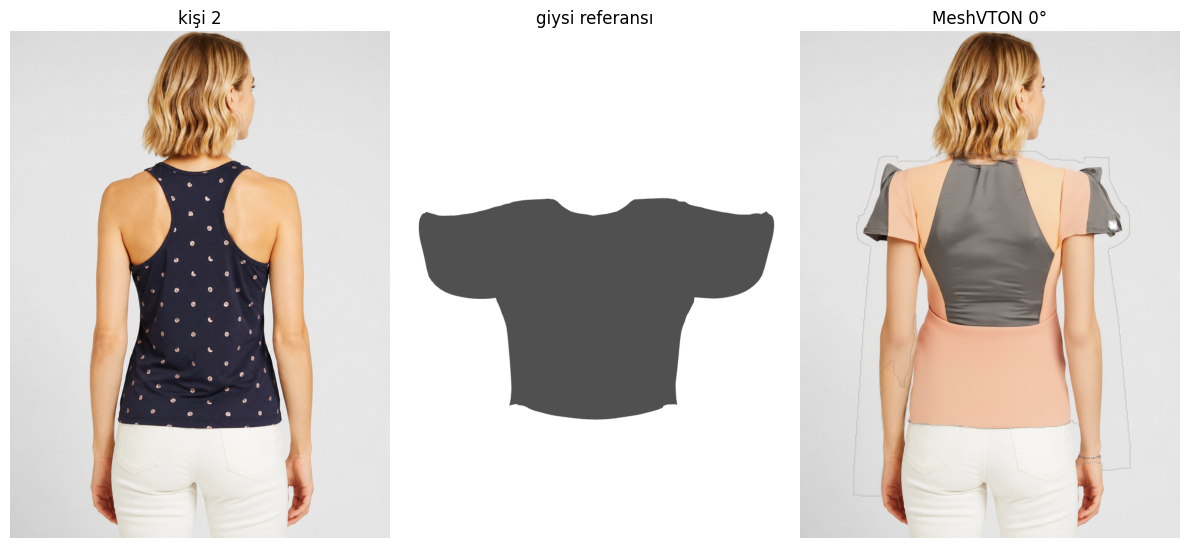


ÜRETİLİYOR: KİŞİ 3 (ChatGPT Image Jul 8, 2026, 10_51_15 PM.png)


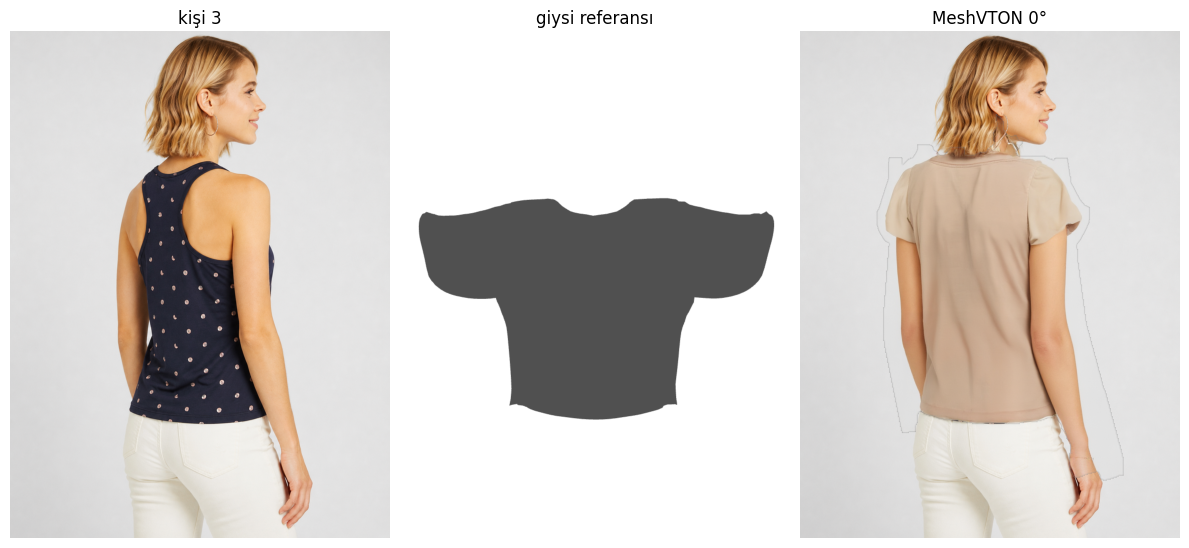


ÜRETİLİYOR: KİŞİ 4 (ChatGPT Image Jul 8, 2026, 10_51_19 PM.png)


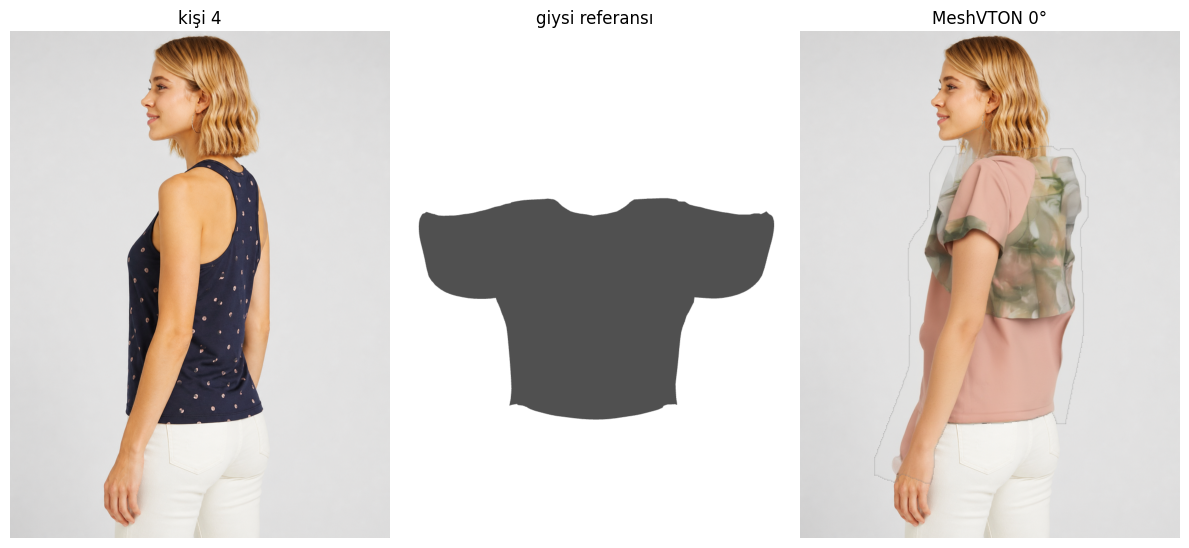

In [ ]:
#@title 6) Try-on üret + göster/kaydet (Tüm kişiler alt alta)
STEPS = 28              #@param
GUIDANCE = 1.0          #@param  1.0 = eğitim değeri; 3.5-30 arası renk doygunluğunu artırabilir
SEED = 0               #@param

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from meshvton2.utils.image_utils import tensor_to_pil
import os

sampler = STATE['sampler']
os.makedirs('/content/results', exist_ok=True)

for p_idx, p_data in enumerate(ALL_PERSON_DATA):
    p_path = p_data['path']
    pp = p_data['pp']
    bundles = p_data['bundles']

    print(f"\n{'='*50}\nÜRETİLİYOR: KİŞİ {p_idx+1} ({os.path.basename(p_path)})")

    results = {}
    for a, bundle in bundles.items():
        pred = sampler.sample(bundle, steps=STEPS, guidance=GUIDANCE, seed=SEED)
        results[a] = pred
        out = f'/content/results/{asset.garment_id}_p{p_idx}_a{a}.png'
        Image.fromarray(pred).save(out)

    appref = np.asarray(tensor_to_pil(next(iter(bundles.values())).appearance_ref))
    cols = 2 + len(results)
    fig, ax = plt.subplots(1, cols, figsize=(4 * cols, 6))
    ax[0].imshow(pp.image);   ax[0].set_title(f'kişi {p_idx+1}')
    ax[1].imshow(appref);     ax[1].set_title('giysi referansı')
    for j, a in enumerate(results):
        ax[2 + j].imshow(results[a]); ax[2 + j].set_title(f'MeshVTON {a}°')
    for x in ax: x.axis('off')
    plt.tight_layout(); plt.show()

In [ ]:
!find /content/MeshVTON/data/garments_3d -name "*.obj"


find: ‘/content/MeshVTON/data/garments_3d’: No such file or directory


In [ ]:
#@title 7) Deney A: guidance sweep (aynı giysi/bundle, sadece guidance değişir)
# Amaç: soluk/tutarsız renklerin nedeni düşük guidance mı, yoksa checkpoint/appearance mi?
GUIDANCES = [1.0, 5.0, 10.0]   #@param

import numpy as np
import matplotlib.pyplot as plt

sampler = STATE['sampler']

for p_idx, p_data in enumerate(ALL_PERSON_DATA):
    pp = p_data['pp']
    bundle0 = p_data['bundles'][0]  # angle=0

    preds = [sampler.sample(bundle0, steps=STEPS, guidance=g, seed=SEED) for g in GUIDANCES]

    fig, ax = plt.subplots(1, 1 + len(preds), figsize=(4 * (1 + len(preds)), 6))
    ax[0].imshow(pp.image); ax[0].set_title(f'kişi {p_idx+1}')
    for j, (g, pred) in enumerate(zip(GUIDANCES, preds)):
        ax[1 + j].imshow(pred); ax[1 + j].set_title(f'guidance={g}')
    for x in ax: x.axis('off')
    plt.tight_layout(); plt.show()

**KALICI KURAL:** Bu projede texture kullanılmıyor — yalnız mesh/geometri yerleşimi test edilir.
Texture'lı giysi kıyaslaması (eski Deney B) bu yüzden kaldırıldı; appearance referansı her zaman
düz gri kalacak. Kötü sonuç teşhisinde yerleşim/drape/kamera tarafına bakılmalı, appearance
referansına değil.

In [ ]:
#@title 9) Deney C: saydamlık/leke HAM üretimde mi yoksa kompozitte mi? + maske sızıntısı
# Amaç: guidance şekli değiştirmiyordu (Deney A) -> sıradaki ayrım: saydamlık/lekeler
# modelin HAM VAE çıktısında mı (composite_outside_mask'in kenar-yumuşatma ÖNCESİ hali,
# return_raw=True) yoksa yalnız kompozit adımında mı ortaya çıkıyor? İkincisi: kişi 2'de
# görülen "eski giysi hayaleti" (gri orta + şeftali yanlar = orijinal racerback kesimiyle
# aynı şekil) gerçekten maske dışında kalan eski giysi pikselinin sızması mı?
import numpy as np
import matplotlib.pyplot as plt

sampler = STATE['sampler']

for p_idx, p_data in enumerate(ALL_PERSON_DATA):
    pp = p_data['pp']
    bundle0 = p_data['bundles'][0]  # angle=0

    composited, raw = sampler.sample(bundle0, steps=STEPS, guidance=GUIDANCE, seed=SEED,
                                      return_raw=True)

    fig, ax = plt.subplots(1, 3, figsize=(12, 6))
    ax[0].imshow(pp.image);   ax[0].set_title(f'kişi {p_idx+1}')
    ax[1].imshow(raw);        ax[1].set_title('HAM üretim (kompozit ÖNCESİ)')
    ax[2].imshow(composited); ax[2].set_title('final (kompozit SONRASI)')
    for x in ax: x.axis('off')
    plt.tight_layout(); plt.show()

    # maske(kırmızı) vs YENİ giysi silüeti(yeşil): maske dışında kalan ama orijinal
    # giysiye ait pikseller kompozitte "eski giysi hayaleti" olarak sızar.
    msk = bundle0.inpaint_mask[0].numpy() > 0.5
    sil = bundle0.control_depth_sil[2].numpy() > 0
    overlay = pp.image.copy()
    overlay[msk] = (overlay[msk] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)
    overlay[sil] = (overlay[sil] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
    plt.figure(figsize=(5, 6))
    plt.imshow(overlay); plt.title(f'kişi {p_idx+1}: maske(kırmızı) vs yeni-silüet(yeşil)')
    plt.axis('off'); plt.show()